In [2]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

In [3]:
wine_data = pd.read_csv('../winequality-white.csv', sep=';')
wine_feat = wine_data.iloc[:, :-1]
wine_target = wine_data.iloc[:, -1]

In [4]:
wine_target

0       6
1       6
2       6
3       6
4       6
       ..
4893    6
4894    5
4895    6
4896    7
4897    6
Name: quality, Length: 4898, dtype: int64

## Descrição preliminar dos dados

O conjunto de dados consiste em **N = 4897** amostras do vinho branco português, chamado "Vinho Verde". A fonte original do dataset inclui amostras de vinhos branco e vermelho, entretanto, como essa variação de tipo pode afetar nos gostos e, portanto, nos resultados preditos, optamos por limitar para aquele do qual temos mais amostras, a saber, o vinho branco. Para a garantia de qualidade e segurança da saúde humana, a indústria de vinhos submete seus produtos a testes fisicoquímicos em laboratório, incluindo a medição de valores como pH ou densidade da bebida, além dos valores melhor detalhados abaixo.

O dataset contém as seguintes informações:
-  Fixed acidity: Concentração de ácido tártaro (g/dm³)
-  Volatile acidity: Concentração de ácido acético (g/dm³)
-  Citric acid: Concentração de ácido cítrico (g/dm³)
-  Residual sugar: Concentração de açúcar residual (g/dm³)
-  Chlorides: Concentração de cloreto de sódio (g/dm³)
-  Free sulfur dioxide: Concentração de dióxido de enxofre livre (mg/dm³)
-  Total sulfur dioxide: Concentração total de dióxido de enxofre (mg/dm³)
-  Density: Densidade do vinho (g/dm³)
-  pH
-  Sulphates: Concentração de sulfato de potássio (g/dm³)
-  Alcohol: Volume de álcool (vol.%)
-  Quality: Qualidade do vinho (classificação inteira entre 0 e 10)

Realizando uma simples análise do conjunto de dados, considerando que desejamos inferir a qualidade de um certo vinho dadas as suas medições laboratoriais, temos que o dataset possui **D = 11** variáveis preditoras, a saber, medições químicas de laboratório, e **L = 11** classes, que são as diferentes classificações do vinho quanto à sua qualidade, que pode variar entre 0 e 10. Posteriormente, analisaremos a distribuição entre classes.

In [5]:
N = wine_data.shape[0]
D = wine_feat.shape[1]
L = 11

<Axes: title={'center': 'Distribuição de classes de vinho branco'}, xlabel='Qualidade do vinho', ylabel='Número de amostras'>

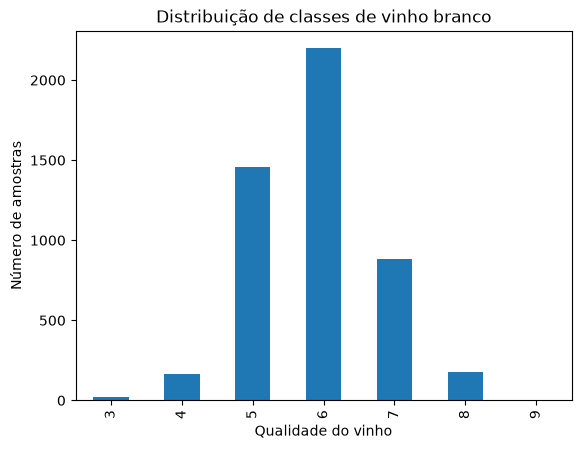

In [6]:
class_distrib = wine_target.value_counts()
class_distrib
class_distrib.sort_index(inplace=True)
class_distrib.plot(kind='bar', title='Distribuição de classes de vinho branco', xlabel='Qualidade do vinho', ylabel='Número de amostras')

Vemos, no resultado acima, uma distribuição equilibrada entre as classes de vinho, concentrando-se em valores médios, enquanto valores extremos (baixos e altos) são escassos. Nota-se que essa distribuição aproxima-se de uma distribuição normal.

## Análise Univariada Incondicional

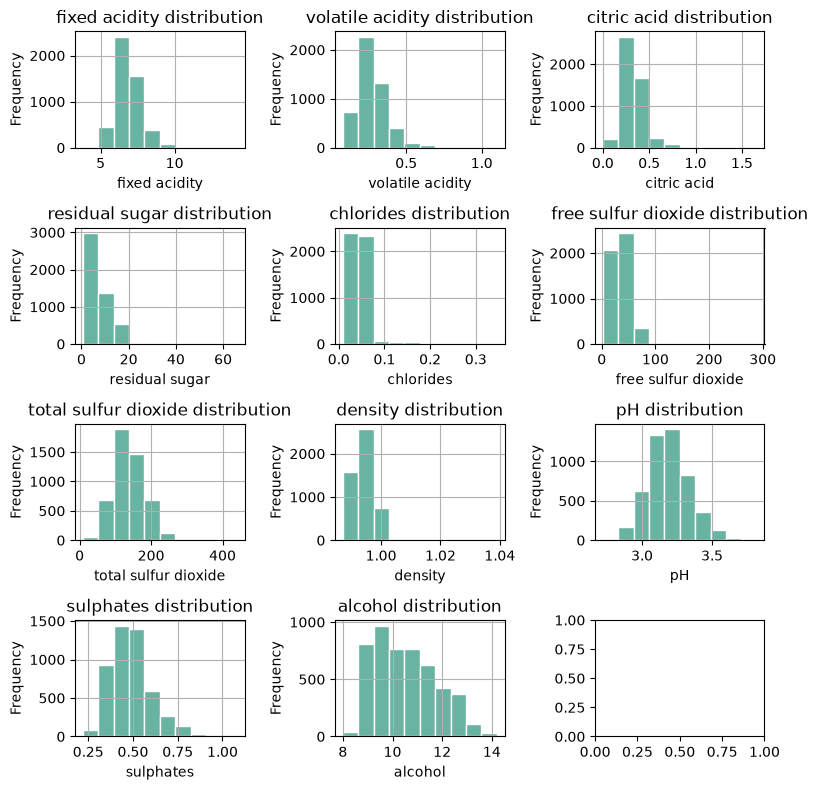

In [7]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(8, 8))

# Flatten the axes array (makes it easier to iterate over)
axes = axes.flatten()

# Loop through each column and plot a histogram
for i, column in enumerate(wine_feat.columns):
    
    # Add the histogram
    wine_feat[column].hist(ax=axes[i], # Define on which ax we're working on
                    edgecolor='white', # Color of the border
                    color='#69b3a2' # Color of the bins
                   )
    
    # Add title and axis label
    axes[i].set_title(f'{column} distribution') 
    axes[i].set_xlabel(column) 
    axes[i].set_ylabel('Frequency') 

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## Os gráficos abaixo são para visualização da equipe, devendo ser filtrados para o que vamos colocar no artigo.

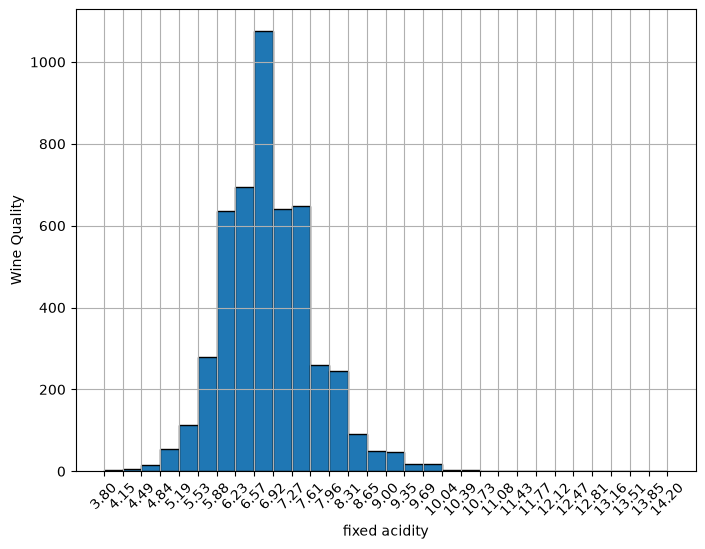

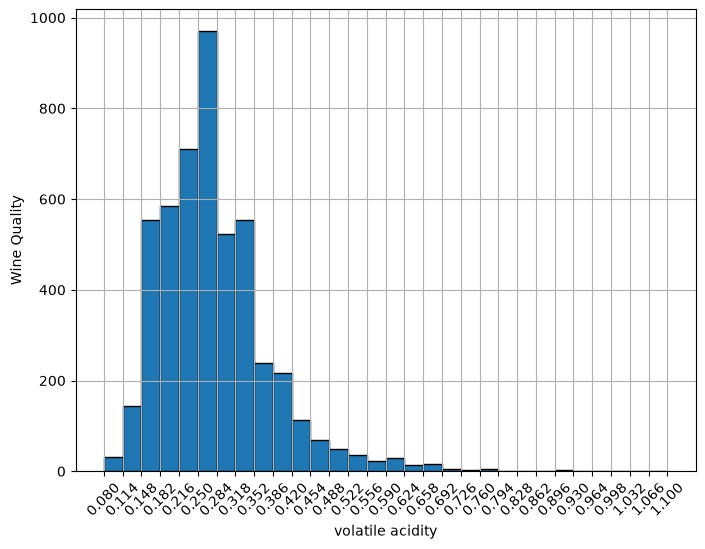

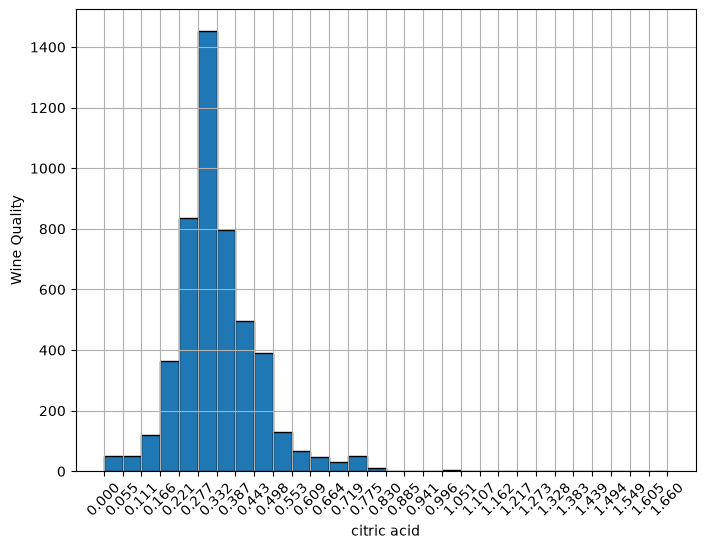

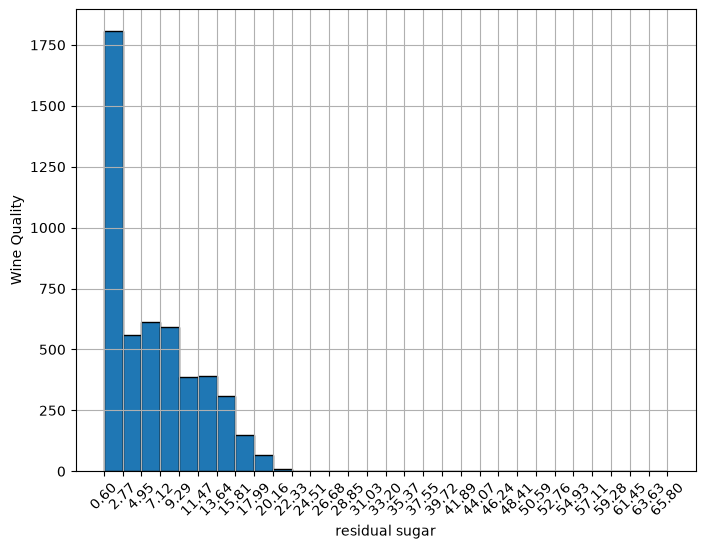

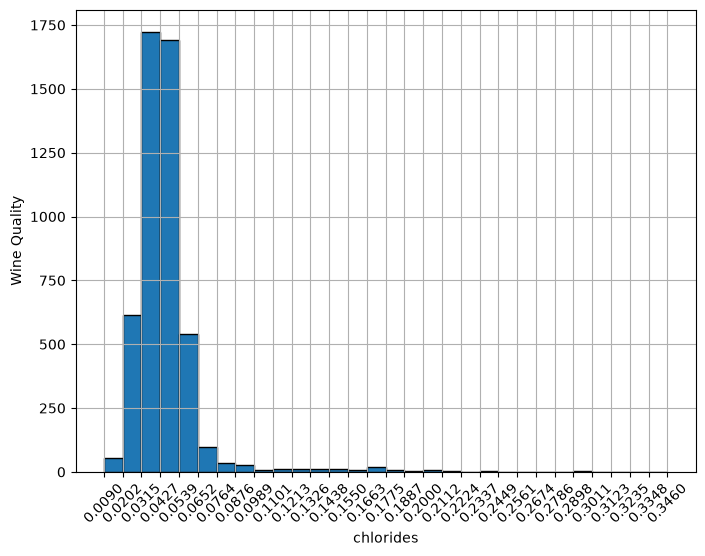

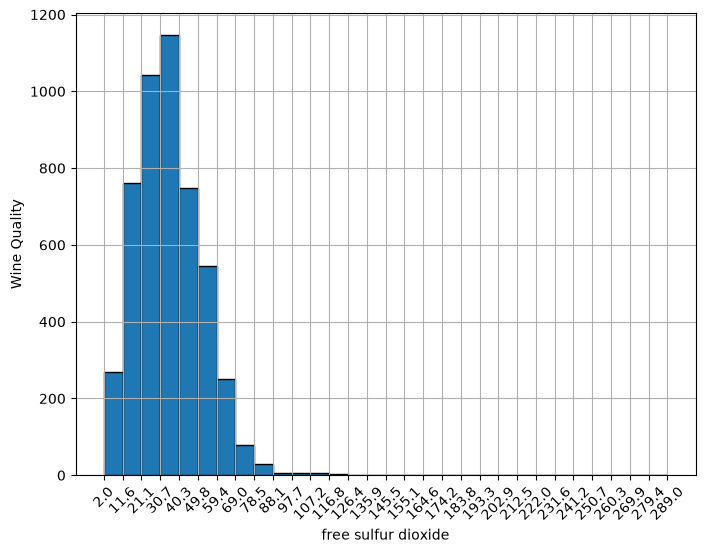

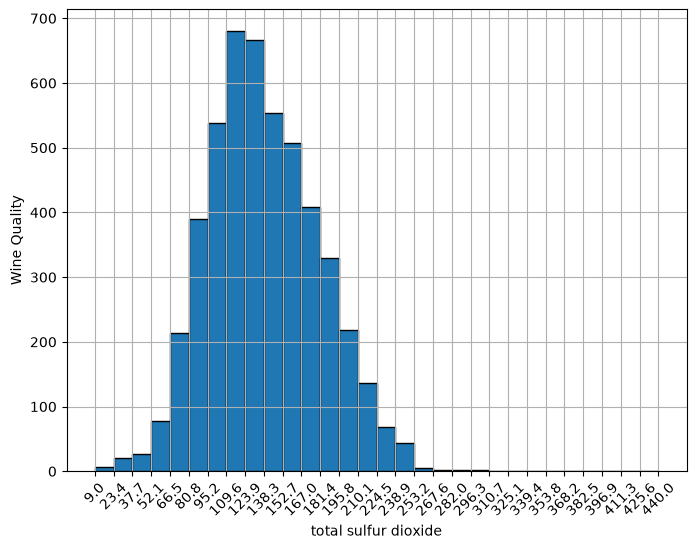

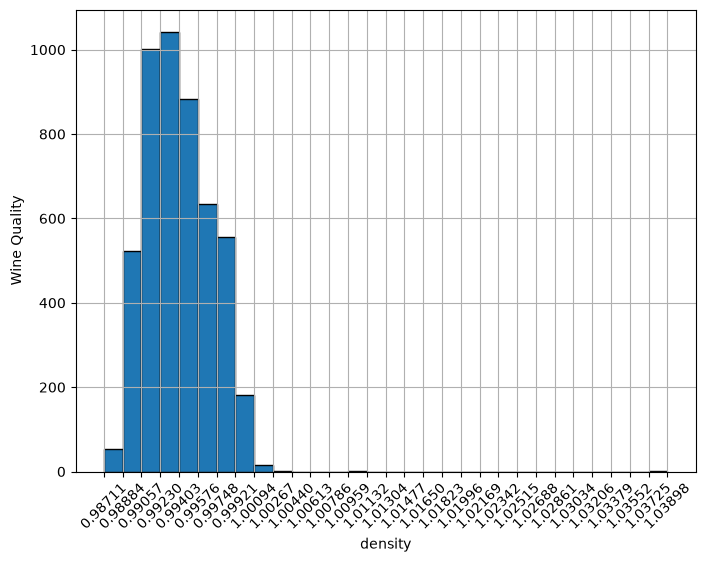

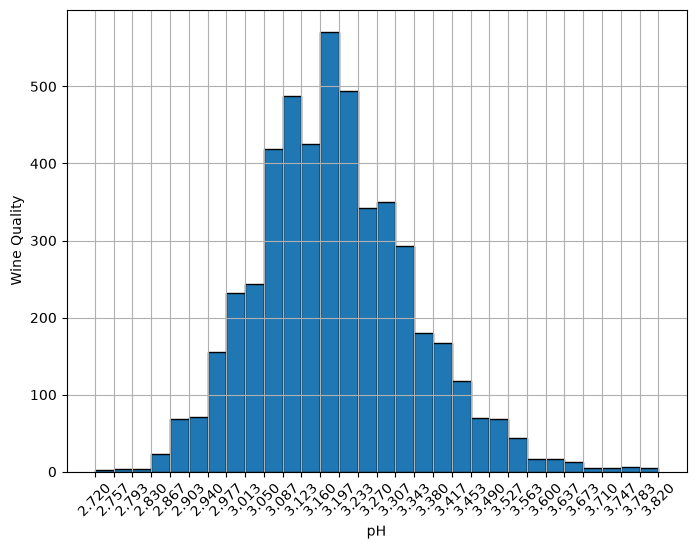

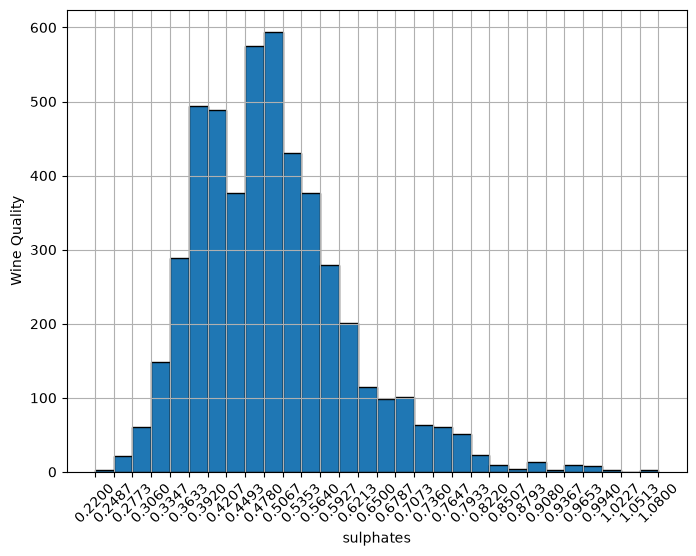

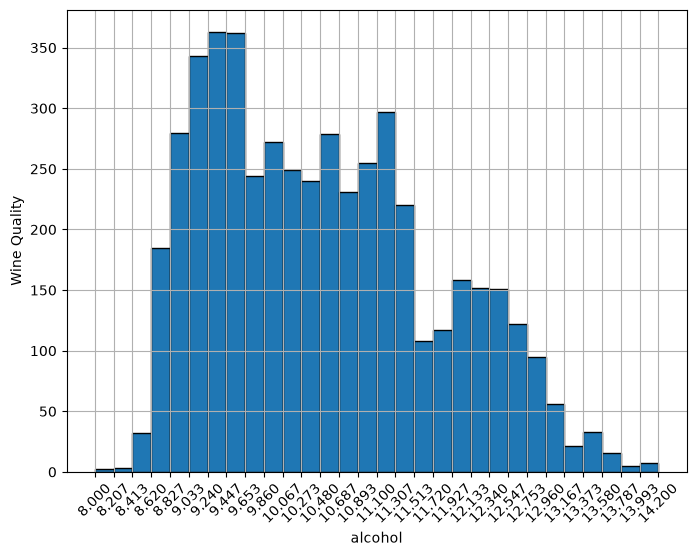

In [17]:
for col in wine_feat.columns:
    plt.figure(figsize=(8, 6))
    n, bins, patches = plt.hist(wine_feat[col], bins=30, edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Wine Quality')
    plt.xticks(bins,
               rotation=45)
    plt.grid()
    plt.show()

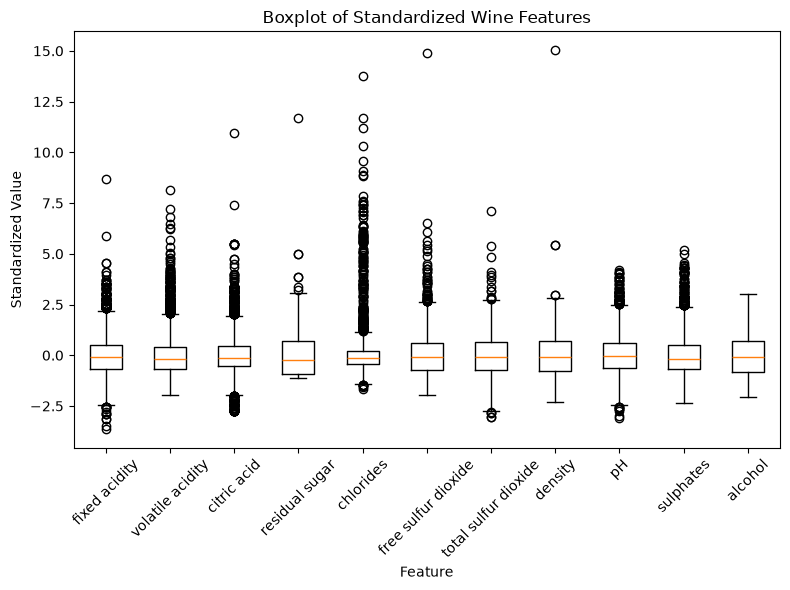

In [11]:
import numpy as np
import pandas as pd

# Juntando features e target para o agrupamento por classe (l)
df_item3 = wine_feat.copy()
df_item3['quality'] = wine_target

# Calculando D x L valores para média, desvio padrão e assimetria
cond_mean = df_item3.groupby('quality').mean()
cond_std = df_item3.groupby('quality').std()
cond_skew = df_item3.groupby('quality').apply(lambda x: x.iloc[:, :-1].skew())

print('Tabela de Médias Condicionais')
display(cond_mean)

print('\nTabela de Desvios Padrão Condicionais')
display(cond_std)

print('\nTabela de Assimetrias Condicionais')
display(cond_skew)

## Os gráficos abaixo são para visualização da equipe, devendo ser filtrados para o que vamos colocar no artigo.

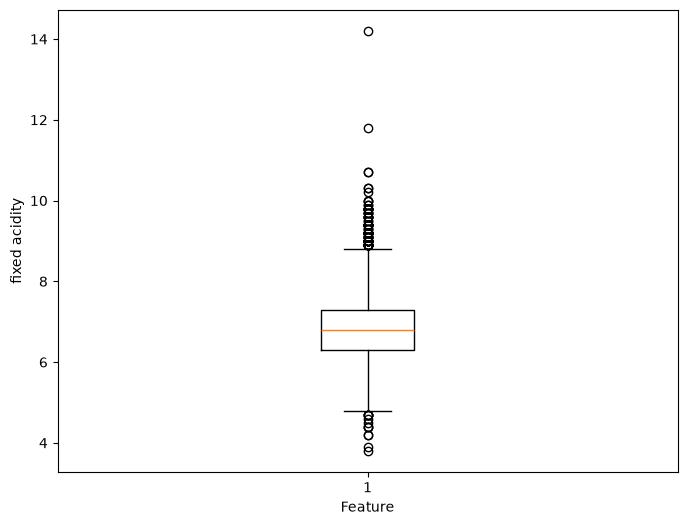

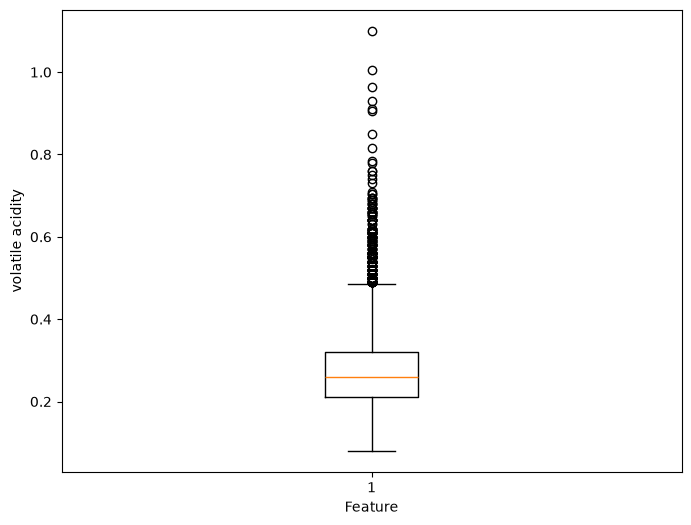

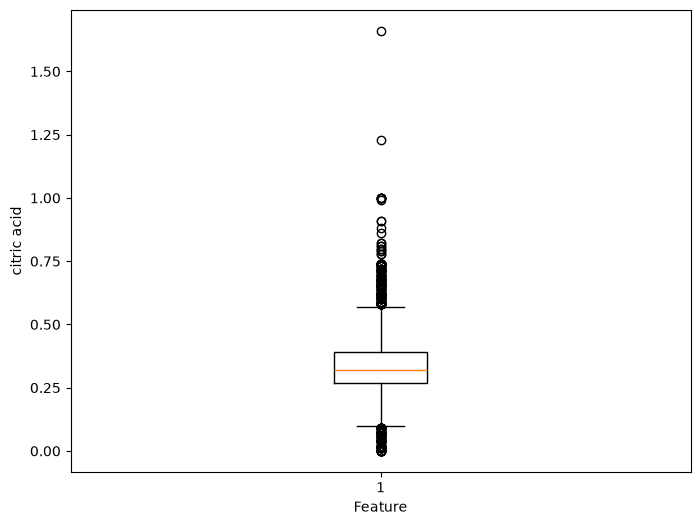

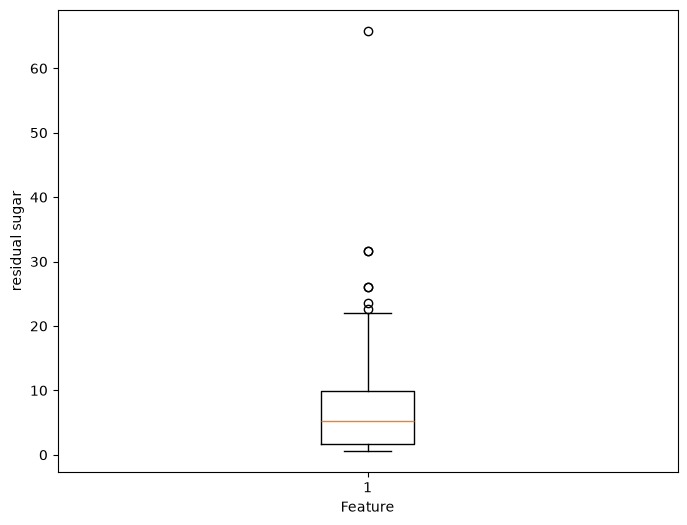

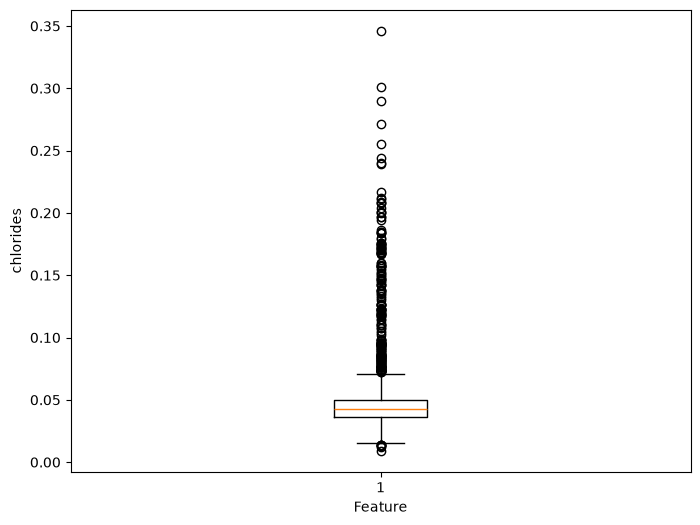

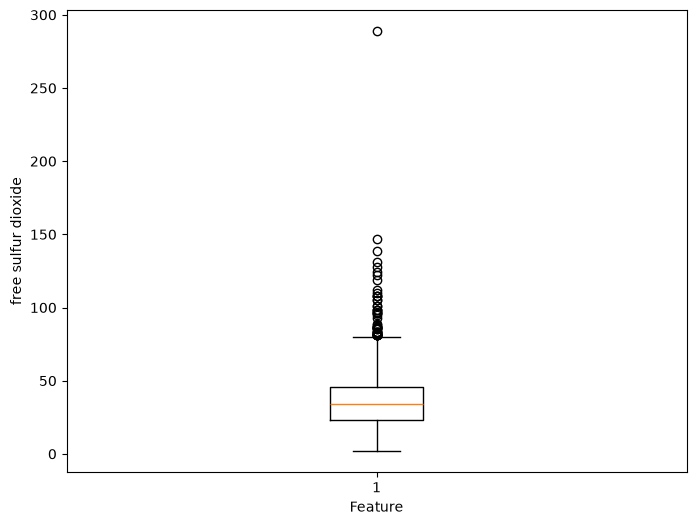

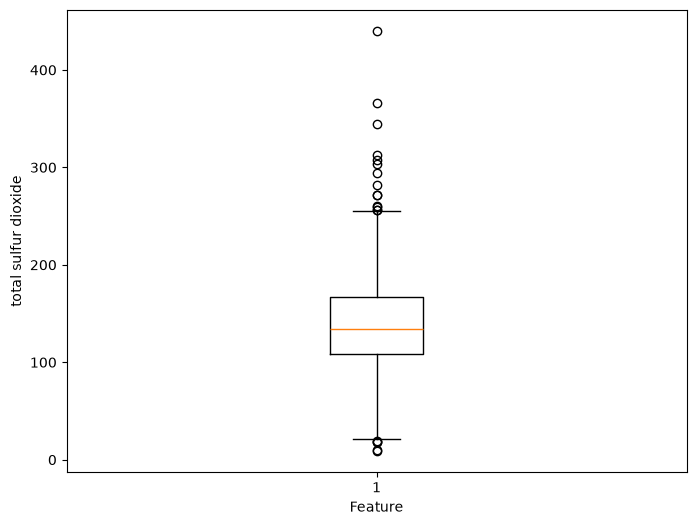

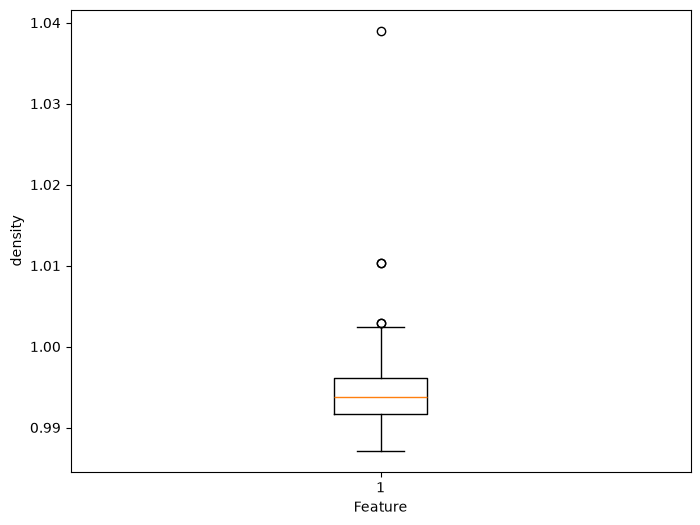

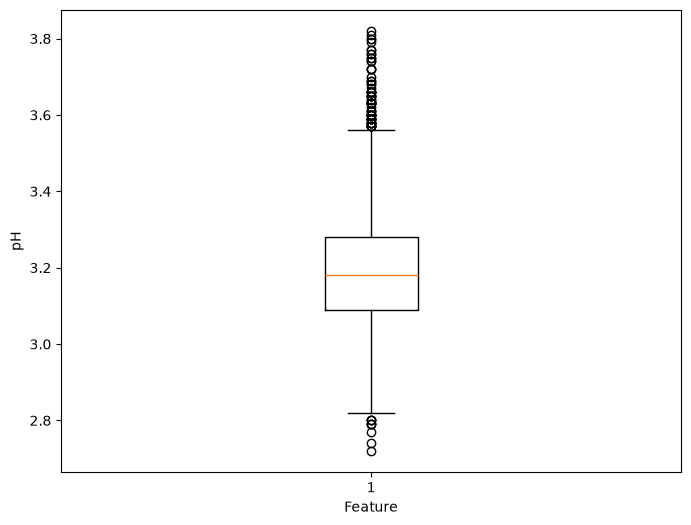

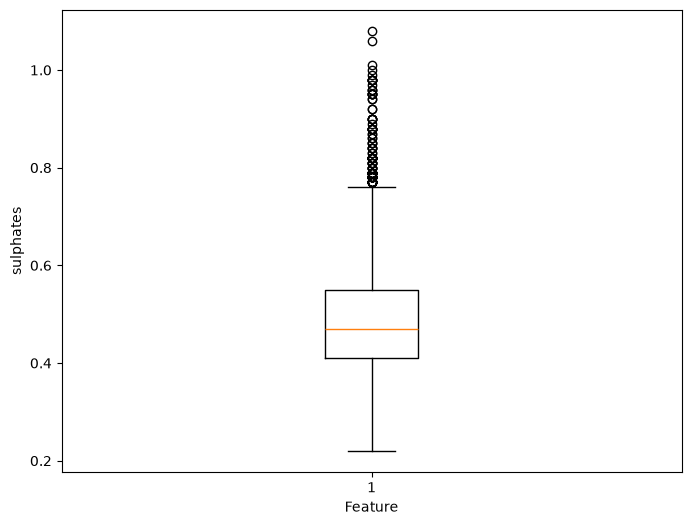

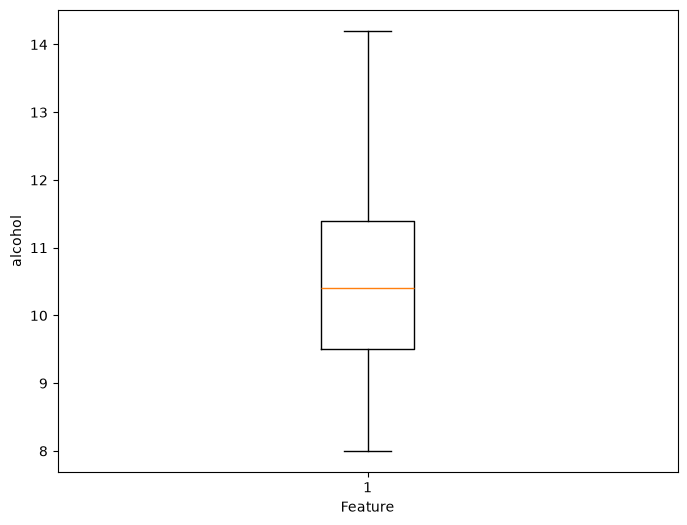

In [38]:
for col in wine_feat.columns:
    plt.figure(figsize=(8, 6))
    plt.boxplot(wine_feat[col])
    plt.ylabel(col)
    plt.xlabel('Feature')
    plt.show()

## Análise Univariada Condicional à Classe

Fazer uma análise univariada condicional à classe é essencial para avaliar o poder preditivo individual de cada variável e entender a separabilidade entre as categorias antes de treinar modelos complexos. Essa etapa permite identificar quais atributos discriminam melhor os dados, detectar sobreposições problemáticas e localizar outliers específicos. Nela, analisamos o preditor de forma isolada, mas separamos os dados de acordo com sua classe, ou seja, analisamos as medições químicas separadamente, porém, considerando os diferentes níveis de qualidade do vinho.

### Histogramas

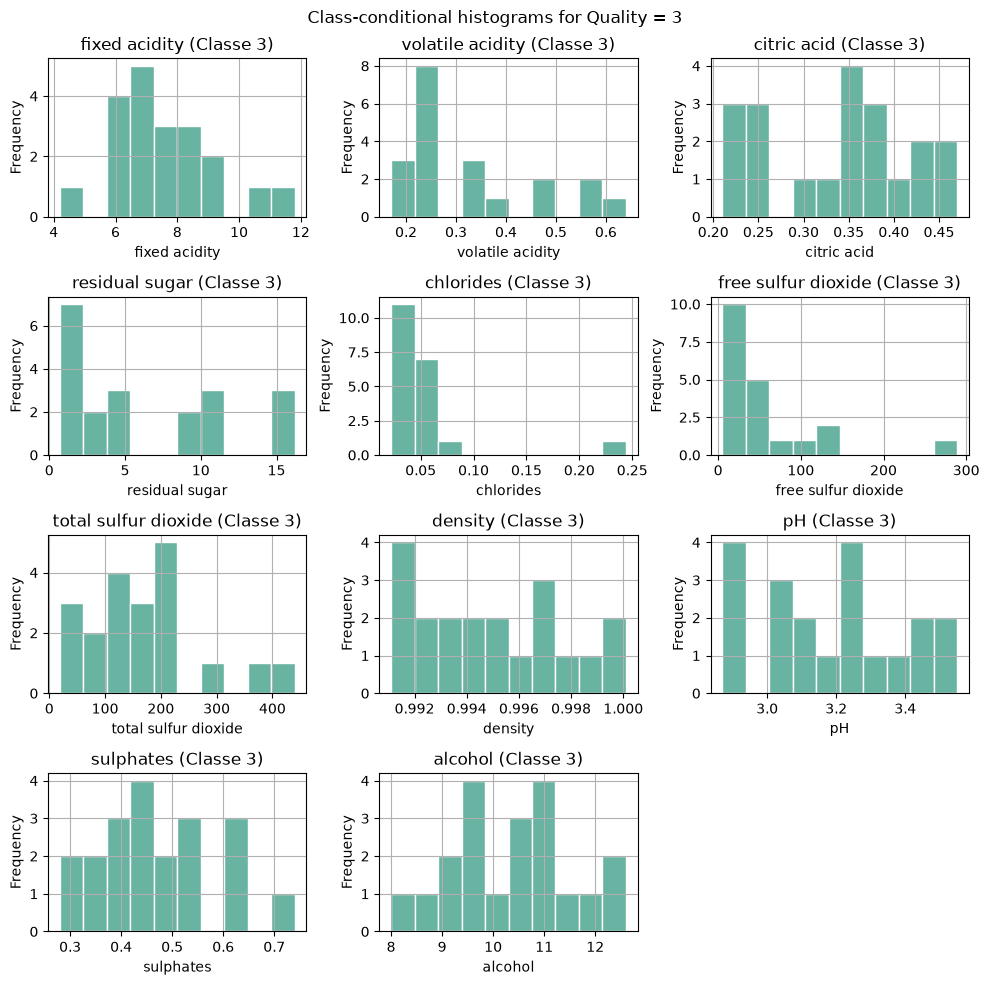

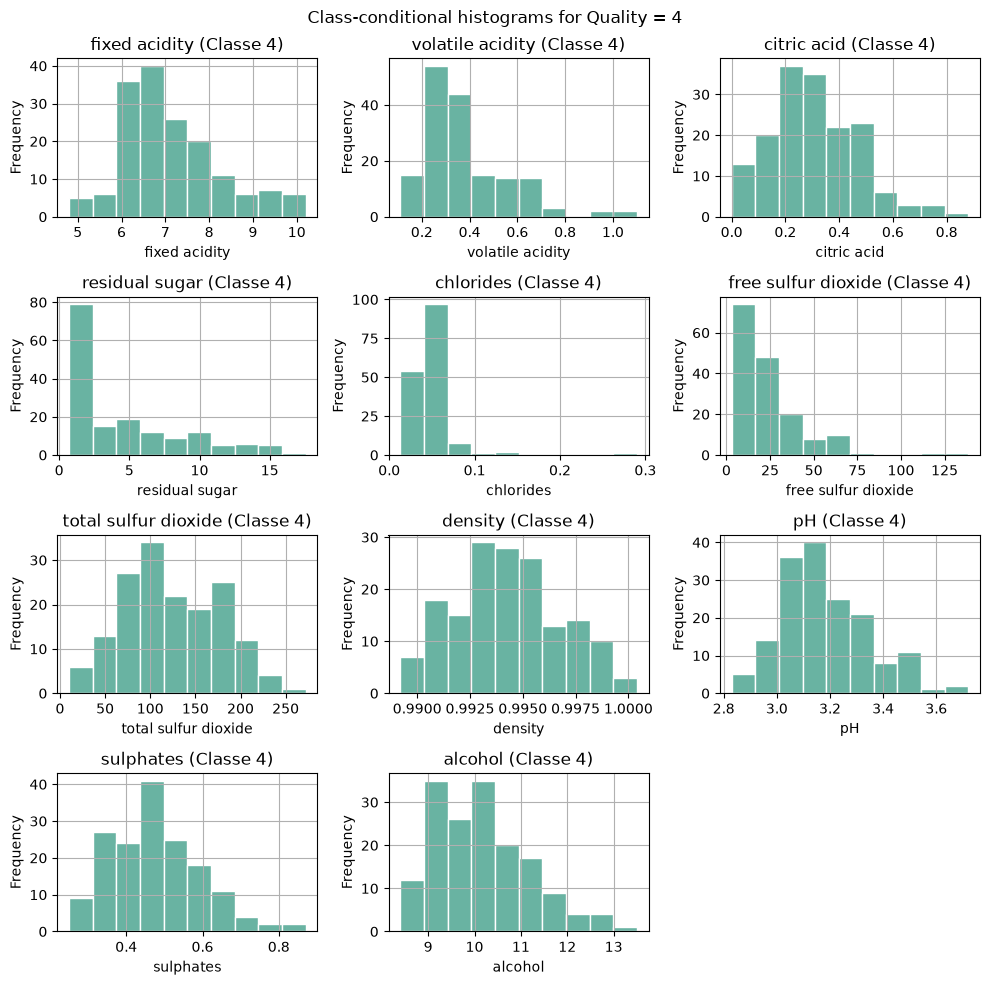

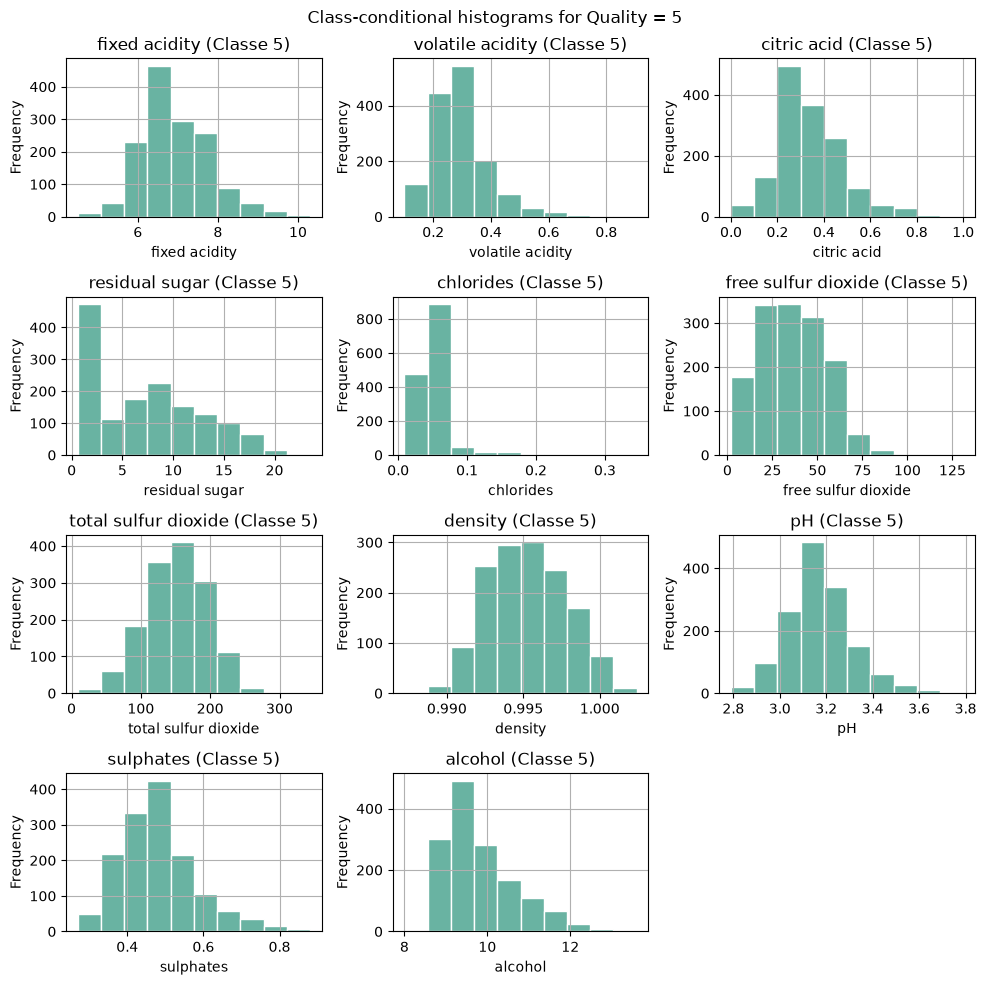

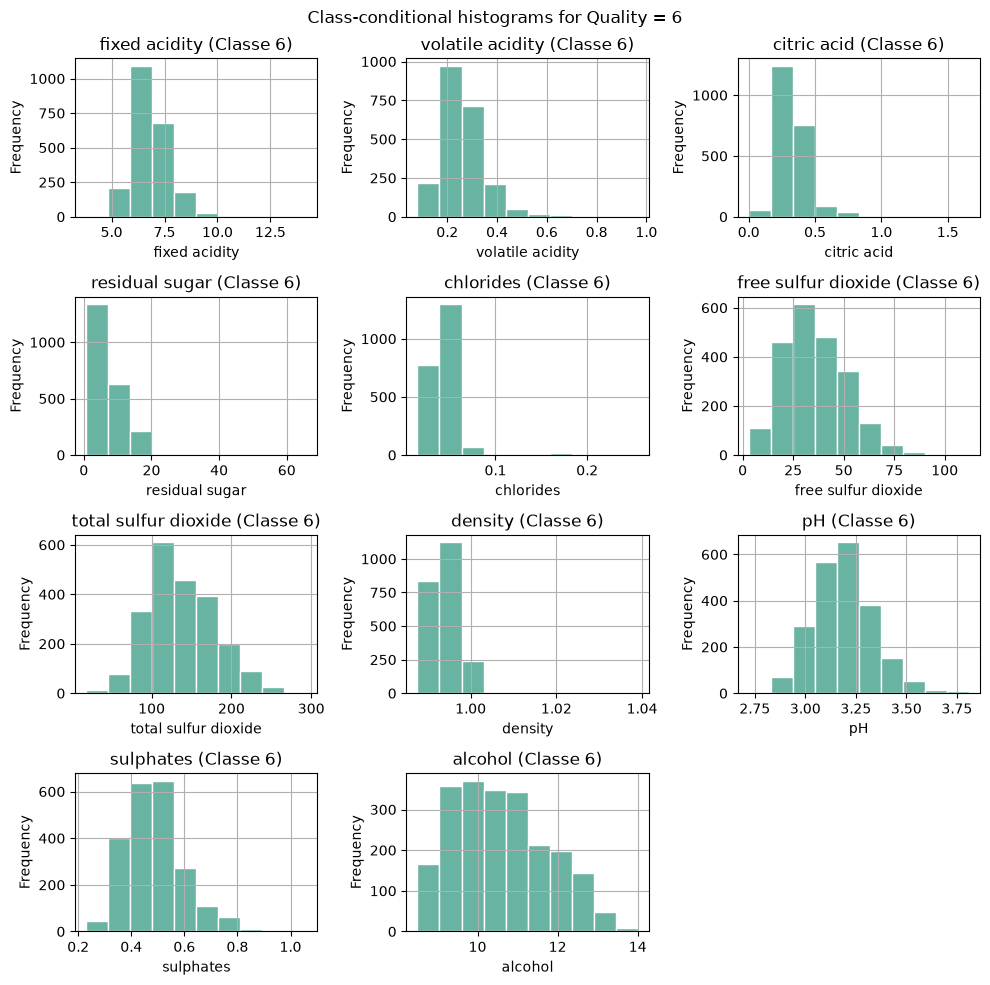

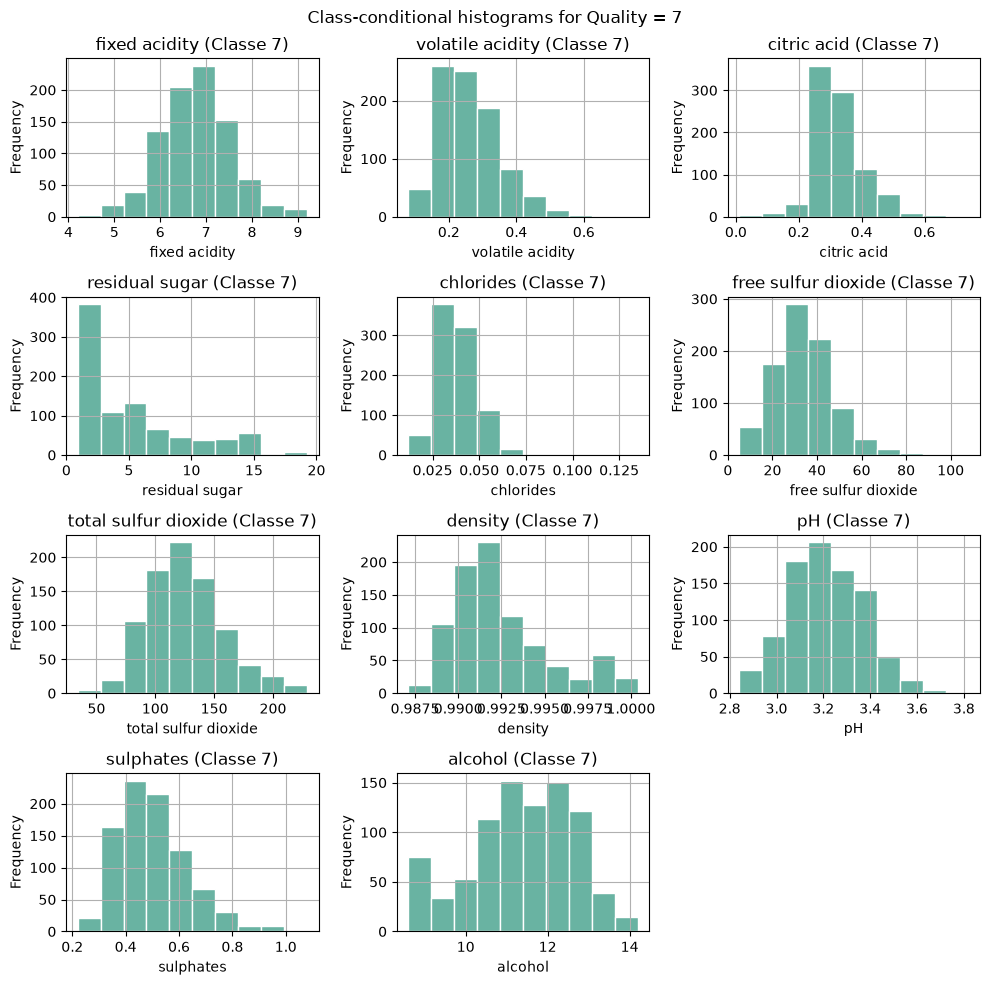

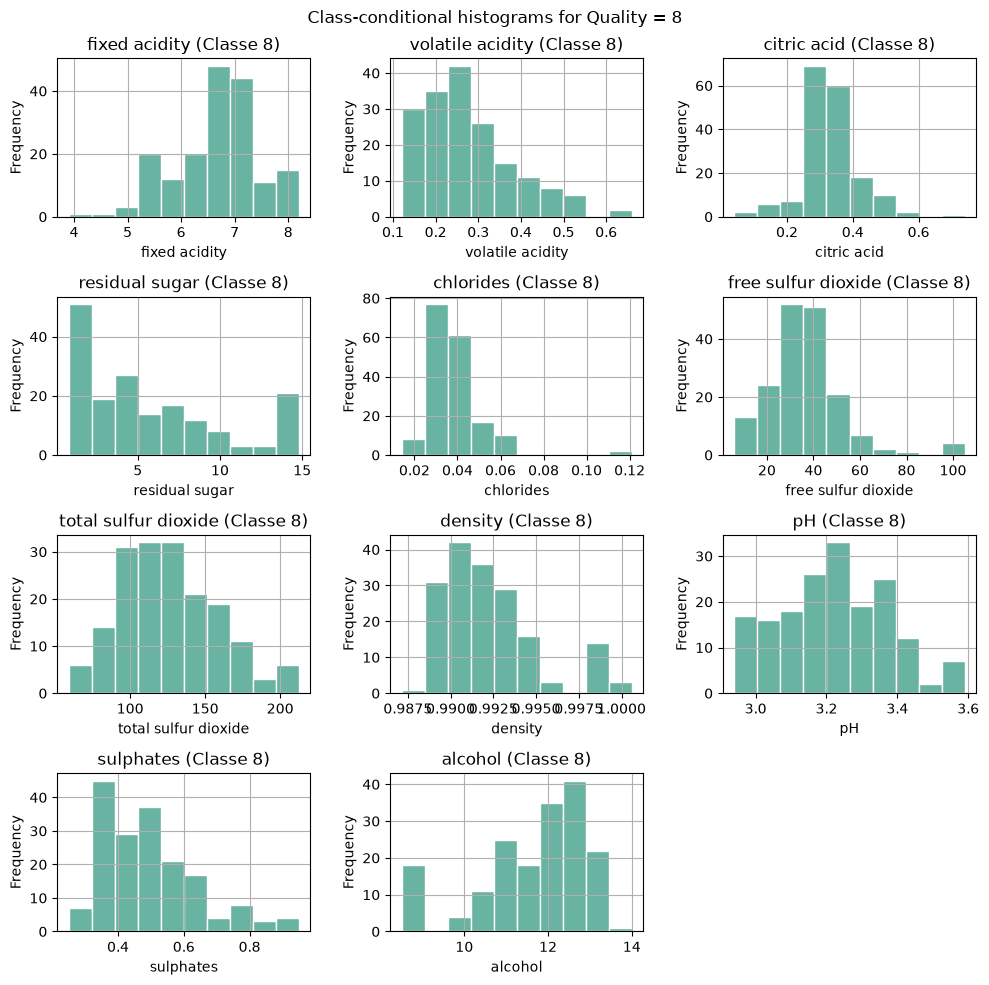

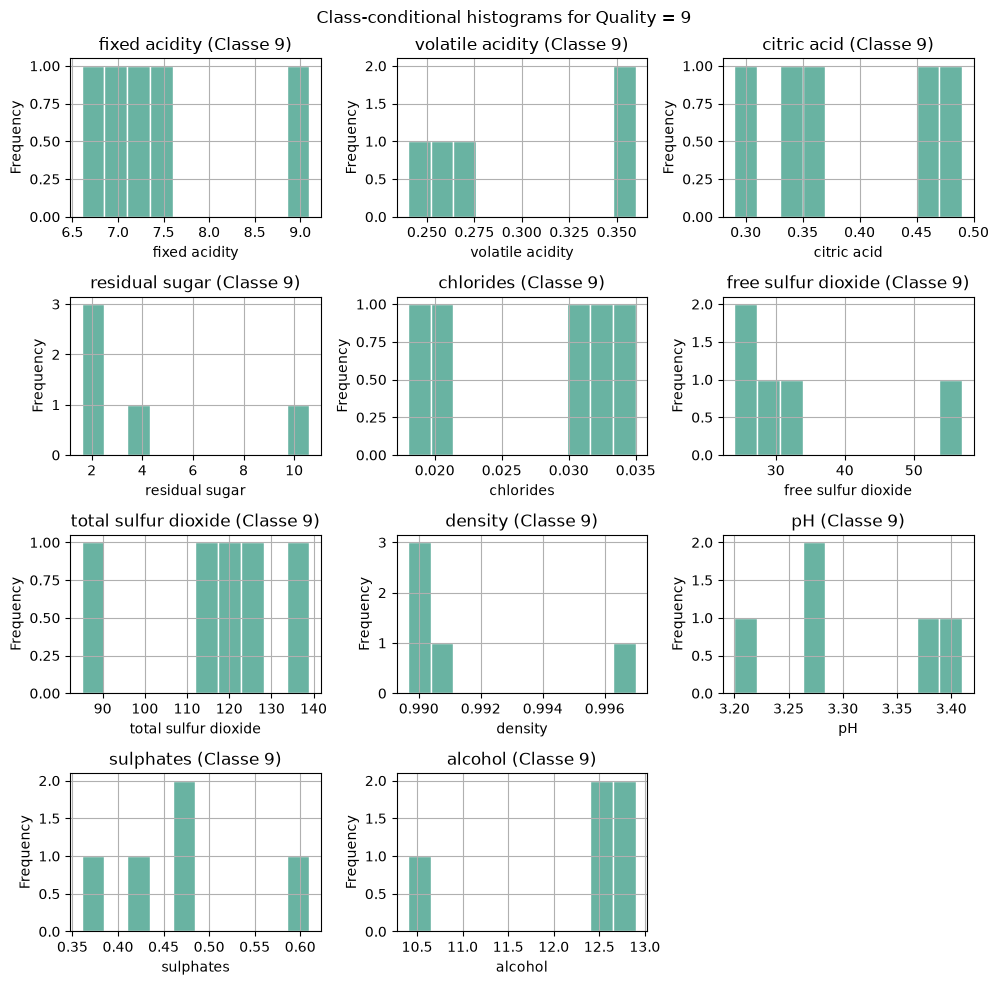

In [13]:
for l in sorted(wine_target.unique()):
  # Filtra as features apenas para a classe atual
  wine_feat_l = wine_feat[wine_target == l]

  fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(10, 10))

  # Flatten the axes array (makes it easier to iterate over)
  axes = axes.flatten()

  # Loop through each column and plot a histogram
  for i, column in enumerate(wine_feat.columns):
    if i < len(axes):
      # Add the histogram para a classe l
      wine_feat_l[column].hist(
          ax=axes[i],  # Define on which ax we're working on
          edgecolor='white',  # Color of the border
          color='#69b3a2',  # Color of the bins
      )

      # Add title and axis label
      axes[i].set_title(f'{column} (Classe {l})')
      axes[i].set_xlabel(column)
      axes[i].set_ylabel('Frequency')

  # Remove subplots vazios caso a grade seja maior que o número de colunas
  for j in range(len(wine_feat.columns), len(axes)):
    fig.delaxes(axes[j])

  # Adjust layout
  plt.suptitle(f'Class-conditional histograms for Quality = {l}', y=0.98)
  plt.tight_layout()

  # Show the plot
  plt.show()

### Box-plot

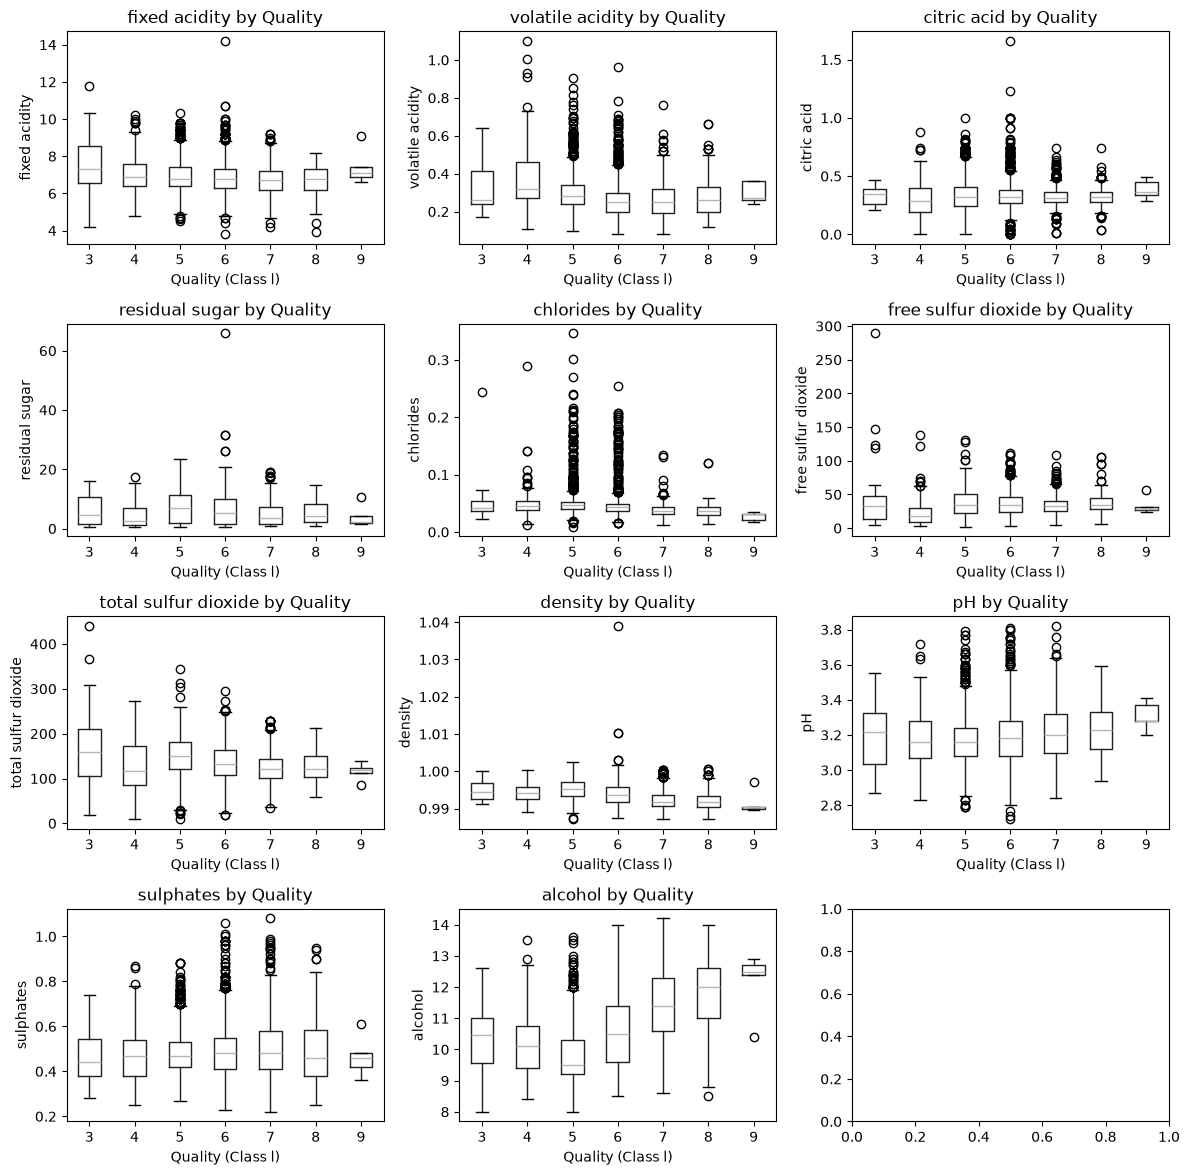

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 12))

# Flatten the axes array (makes it easier to iterate over)
axes = axes.flatten()

# Loop through each column and plot a box-plot grouped by quality
for i, column in enumerate(wine_feat.columns):
  if i < len(axes):
    # Add the box-plot grouped by the target class
    wine_data.boxplot(
        column=column,
        by='quality',
        ax=axes[i],  # Define on which ax we're working on
        grid=False,
    )

    # Add title and axis label
    axes[i].set_title(f'{column} by Quality')
    axes[i].set_xlabel('Quality (Class l)')
    axes[i].set_ylabel(column)

# Remove the automatic suptitle generated by pandas boxplot
plt.suptitle('')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

### Valores incondicionais

In [42]:
df_estatisticas = pd.DataFrame({
    'Média': wine_feat.mean(),
    'Desvio Padrão': wine_feat.std(),
    'Skewness': wine_feat.skew(),
})

print('Tabela de Estatísticas Incondicionais dos Preditores')
display(df_estatisticas)

Tabela de Estatísticas Incondicionais dos Preditores


,Média,Desvio Padrão,Skewness
fixed acidity,6.854788,0.843868,0.647751
volatile acidity,0.278241,0.100795,1.576980
citric acid,0.334192,0.121020,1.281920
residual sugar,6.391415,5.072058,1.077094
chlorides,0.045772,0.021848,5.023331
free sulfur dioxide,35.308085,17.007137,1.406745
total sulfur dioxide,138.360657,42.498065,0.390710
density,0.994027,0.002991,0.977773
pH,3.188267,0.151001,0.457783
sulphates,0.489847,0.114126,0.977194


Com base nesses resultados, podemos analisar que nenhum preditor, tomado isoladamente (mono-variado), é capaz de separar perfeitamente todas as classes de qualidade. Existe uma sobreposição massiva nos valores da maioria das variáveis entre as classes adjacentes. Diante disso, o teor alcoólico é o que demonstra o maior poder discriminativo individual. Observa-se uma tendência clara em que os vinhos com notas mais altas possuem distribuições de álcool deslocadas para valores visivelmente superiores em comparação aos vinhos de notas mais baixas.

Além disso, um fato marcante na exploração dos dados é que a escala teórica de qualidade (quality) vai de 0 a 10 ($L=11$), mas as classes extremas (como 0, 1, 2 e 10) praticamente não possuem observações ou contêm amostras extremamente escassas. Isso faz com que as estatísticas (média, desvio padrão e assimetria) nessas classes fiquem instáveis ou resultem em valores nulos.

Ademais, variáveis como açúcar residual (residual sugar) e cloretos (chlorides) apresentam forte assimetria positiva ($\gamma$) em quase todas as classes, indicando caudas longas à direita devido a valores atípicos elevados.

## Análise Bi-variada Incondicional

### Mapa de Calor

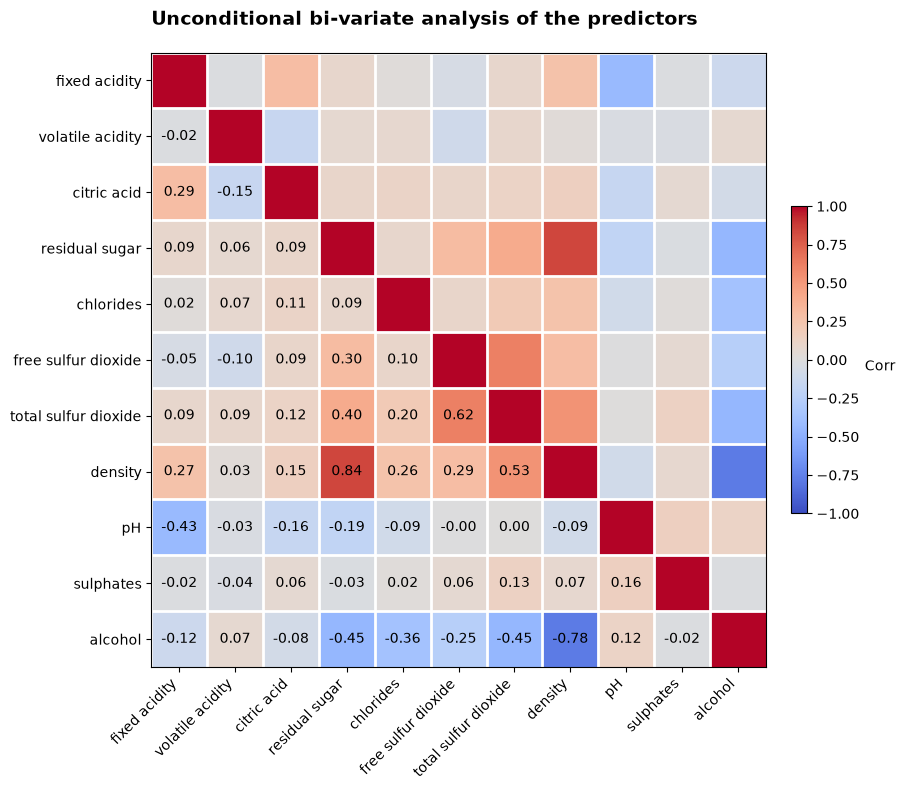

In [35]:
corr_matrix = wine_feat.corr()

# 2. Criando a figura com o estilo visual semelhante ao da imagem (fundo cinza e grid branco)
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor('#e0e0e0')  # Fundo cinza claro estilo ggplot
fig.patch.set_facecolor('white')

# Desenhando o heatmap completo com colormap divergente (azul para negativo, laranja para positivo)
cax = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Adicionando a barra de cores lateral com o rótulo 'Corr'
cbar = fig.colorbar(cax, ax=ax, shrink=0.5, pad=0.03)
cbar.set_label('Corr', rotation=0, labelpad=15)

# Configurando os ticks e nomes das colunas
ticks = np.arange(len(wine_feat.columns))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(wine_feat.columns, rotation=45, ha='right')
ax.set_yticklabels(wine_feat.columns)

# Linhas de grade brancas para separar as células
ax.set_xticks(ticks - 0.5, minor=True)
ax.set_yticks(ticks - 0.5, minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)

# Adicionando os valores numéricos apenas na parte inferior (triangular) como na referência
for i in range(len(wine_feat.columns)):
  for j in range(len(wine_feat.columns)):
    if i > j:  # Exibe apenas a parte inferior do triângulo
      val = corr_matrix.iloc[i, j]
      ax.text(
          j,
          i,
          f'{val:.2f}',
          ha='center',
          va='center',
          color='black',
          fontsize=10,
      )

plt.title(
    'Unconditional bi-variate analysis of the predictors',
    fontsize=14,
    pad=20,
    weight='bold',
    loc='left',
)
plt.tight_layout()
plt.show()

### Scatter plot

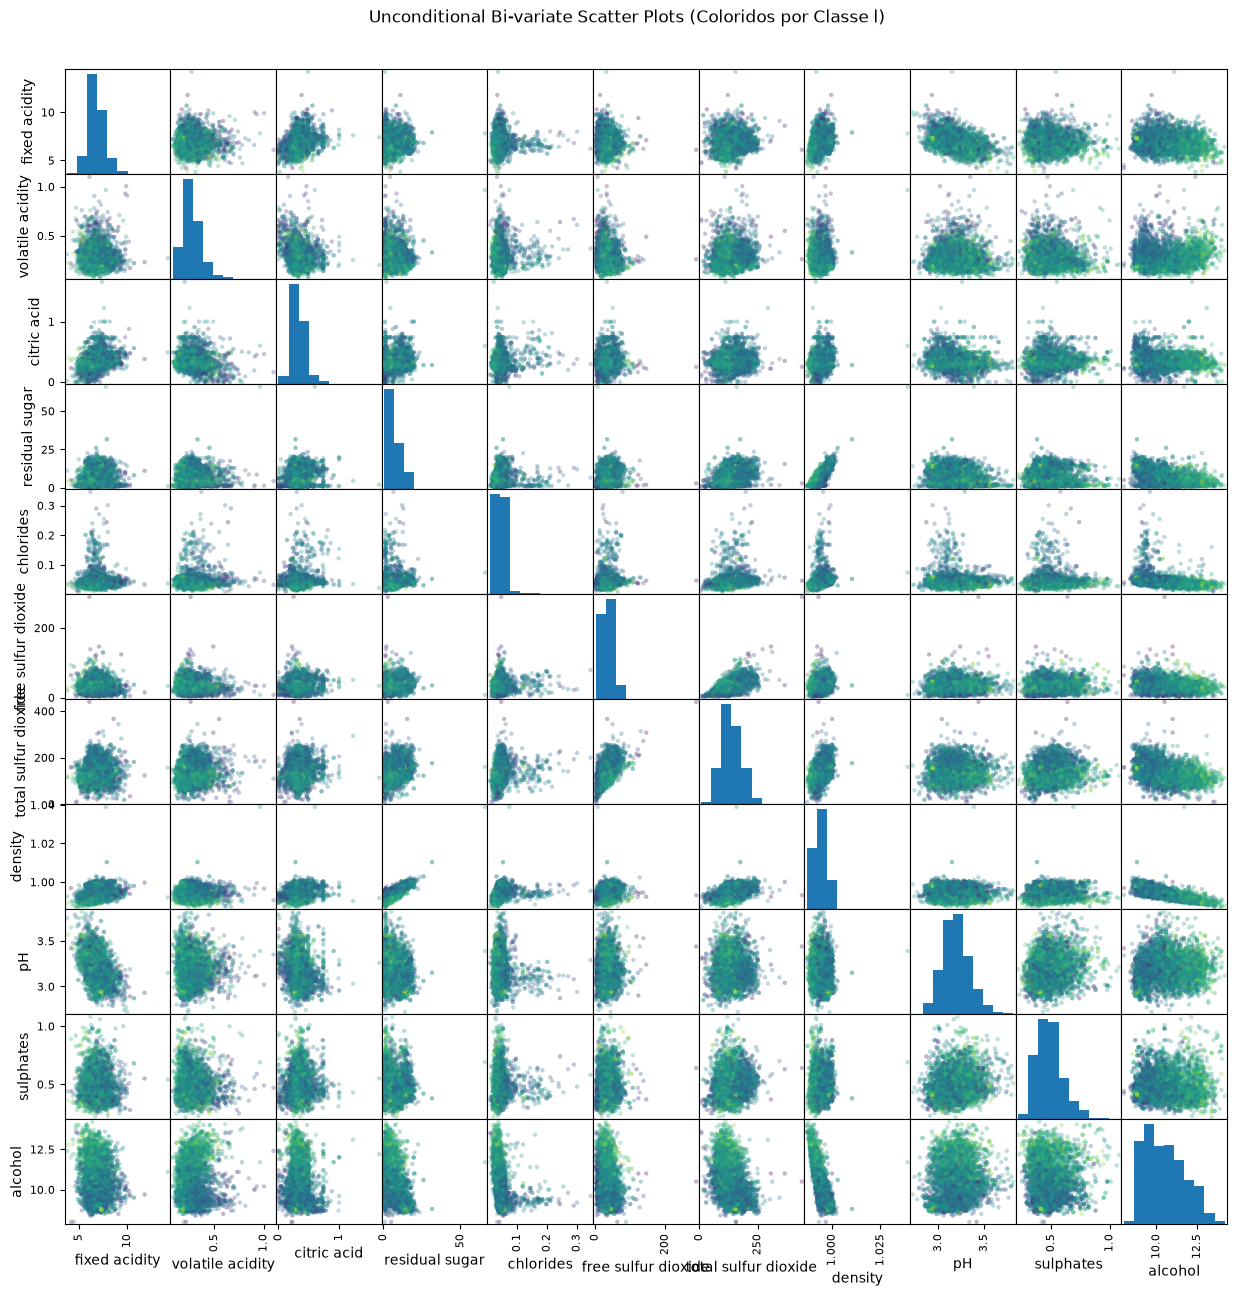

In [37]:
pd.plotting.scatter_matrix(
    wine_feat,
    alpha=0.3,
    figsize=(15, 15),
    diagonal='hist',
    c=wine_target,
    cmap='viridis',
    marker='o',
    s=10,
)

plt.suptitle(
    'Unconditional Bi-variate Scatter Plots (Coloridos por Classe l)', y=0.92
)
plt.show()